# ASL 3-Layer Linear Classifier

Three stacked linear layers for Sign Language MNIST CSVs in data/asl_data, with training/validation metric plots.

In [16]:

from pathlib import Path
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Paths and hyperparameters
DATA_DIR = Path("data/asl_data")
TRAIN_CSV = DATA_DIR / "sign_mnist_train.csv"
VALID_CSV = DATA_DIR / "sign_mnist_valid.csv"

hyperparams = {
    "epochs": 10,
    "lr": 1e-3,
    "batch_size": 128,
    "hidden_dims": [256, 128],
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [17]:

def load_csv_as_tensors(csv_path: Path):
    """Load Sign-MNIST CSV -> (images, labels) tensors."""
    df = pd.read_csv(csv_path)
    labels = torch.tensor(df.pop("label").values, dtype=torch.long)
    images = torch.tensor(df.values, dtype=torch.float32) / 255.0  # scale to [0, 1]
    return images, labels

train_x, train_y = load_csv_as_tensors(TRAIN_CSV)
valid_x, valid_y = load_csv_as_tensors(VALID_CSV)
print(f"Train set: {train_x.shape}, Valid set: {valid_x.shape}")


Train set: torch.Size([27455, 784]), Valid set: torch.Size([7172, 784])


In [18]:

train_ds = TensorDataset(train_x, train_y)
valid_ds = TensorDataset(valid_x, valid_y)

train_loader = DataLoader(train_ds, batch_size=hyperparams["batch_size"], shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=hyperparams["batch_size"], shuffle=False)
num_classes = int(torch.unique(train_y).numel())
print(f"Classes: {num_classes}")


Classes: 24


In [19]:

h1, h2 = hyperparams["hidden_dims"]
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, h1),
    nn.ReLU(),
    nn.Linear(h1, h2),
    nn.ReLU(),
    nn.Linear(h2, num_classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams["lr"])
print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=24, bias=True)
)


In [20]:

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss_sum += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, correct / total

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(1, hyperparams["epochs"] + 1):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = loss_sum / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, valid_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")


Epoch 01 | train_loss=2.4592 | train_acc=0.2531 | val_loss=1.9694 | val_acc=0.3629
Epoch 02 | train_loss=1.5681 | train_acc=0.4988 | val_loss=1.5571 | val_acc=0.4954
Epoch 03 | train_loss=1.2250 | train_acc=0.6024 | val_loss=1.3376 | val_acc=0.5611
Epoch 04 | train_loss=0.9794 | train_acc=0.6885 | val_loss=1.3677 | val_acc=0.5844
Epoch 05 | train_loss=0.8058 | train_acc=0.7456 | val_loss=1.2646 | val_acc=0.6129
Epoch 06 | train_loss=0.6464 | train_acc=0.7987 | val_loss=1.1239 | val_acc=0.6514
Epoch 07 | train_loss=0.5494 | train_acc=0.8288 | val_loss=1.1306 | val_acc=0.6654
Epoch 08 | train_loss=0.4494 | train_acc=0.8643 | val_loss=1.1361 | val_acc=0.6693
Epoch 09 | train_loss=0.3628 | train_acc=0.8950 | val_loss=1.1912 | val_acc=0.6371
Epoch 10 | train_loss=0.3013 | train_acc=0.9140 | val_loss=1.1226 | val_acc=0.6707


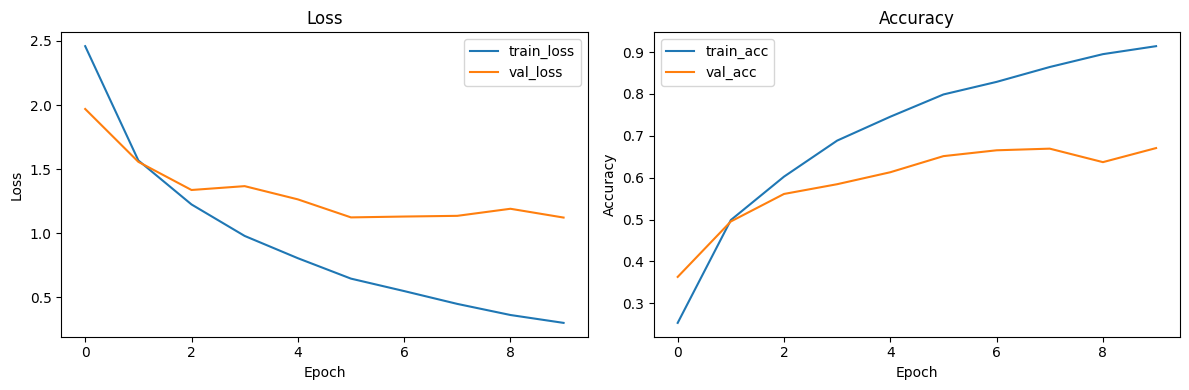

Last epoch stats -> train_loss: 0.3013, train_acc: 0.9140, val_loss: 1.1226, val_acc: 0.6707


In [22]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train_loss")
axes[0].plot(val_losses, label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train_acc")
axes[1].plot(val_accs, label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

last_epoch = len(train_losses)
print(f"Last epoch stats -> train_loss: {train_losses[-1]:.4f}, train_acc: {train_accs[-1]:.4f}, val_loss: {val_losses[-1]:.4f}, val_acc: {val_accs[-1]:.4f}")
